# Local Search - Data Center Network Topology Design

Eksperimen **keempat varian Hill-Climbing** (Steepest-Ascent, Sideways Move, Stochastic,
Random Restart), Simulated Annealing, dan Genetic Algorithm pada satu instance yang sama.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join("..", "..", "src", "local_search")))

import numpy as np
from topology import generate_positions, random_initial_state, describe_state, objective
from algorithms import (
    hill_climbing_steepest_ascent,
    hill_climbing_sideways,
    hill_climbing_stochastic,
    hill_climbing_random_restart,
    simulated_annealing,
    genetic_algorithm,
)

SEED = 42
N = 12
K_MAX = 4
WEIGHTS = dict(w_L=1.0, w_C=1.0, w_B=0.5, w_D=1.0)
PENALTY_BIG = 50.0

rng = np.random.default_rng(SEED)
positions = generate_positions(N, seed=SEED)
A0 = random_initial_state(N, K_MAX, rng)
print(describe_state(A0, positions, WEIGHTS, PENALTY_BIG))

Jumlah edge : 18
Edge list   : [(0, 1), (0, 4), (0, 10), (0, 11), (1, 6), (1, 7), (1, 9), (2, 9), (2, 10), (3, 4), (3, 7), (3, 9), (3, 11), (4, 5), (4, 6), (6, 10), (8, 9), (8, 10)]
Degree/node : [4, 4, 2, 4, 4, 1, 3, 2, 2, 4, 4, 2]
cost=2.7453 | latency=2.0000 | cable_cost=0.2453 | bridges=1 | components=1


## Hill-Climbing 1/4 - Steepest-Ascent (Basic)

In [2]:
hc_final, hc_history = hill_climbing_steepest_ascent(A0, K_MAX, positions, WEIGHTS, PENALTY_BIG, max_iter=300)
print(f"Iterasi hingga local optimum: {len(hc_history) - 1}")
print(describe_state(hc_final, positions, WEIGHTS, PENALTY_BIG))

Iterasi hingga local optimum: 6
Jumlah edge : 23
Edge list   : [(0, 1), (0, 4), (0, 10), (0, 11), (1, 6), (1, 7), (1, 9), (2, 5), (2, 9), (2, 10), (3, 6), (3, 7), (3, 9), (3, 11), (4, 5), (4, 6), (4, 8), (5, 7), (5, 11), (6, 10), (7, 8), (8, 9), (8, 10)]
Degree/node : [4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 3]
cost=1.9625 | latency=1.6667 | cable_cost=0.2959 | bridges=0 | components=1


## Hill-Climbing 2/4 - Sideways Move

Menerima juga neighbor ber-cost **sama** agar bisa menyeberangi *plateau*, dibatasi
`max_sideways` langkah mendatar berturut-turut supaya tidak berputar selamanya.

In [3]:
sw_final, sw_history = hill_climbing_sideways(
    A0, K_MAX, positions, WEIGHTS, PENALTY_BIG, max_iter=300, max_sideways=25)
print(f"Iterasi: {len(sw_history) - 1}")
print(describe_state(sw_final, positions, WEIGHTS, PENALTY_BIG))

Iterasi: 6
Jumlah edge : 23
Edge list   : [(0, 1), (0, 4), (0, 10), (0, 11), (1, 6), (1, 7), (1, 9), (2, 5), (2, 9), (2, 10), (3, 6), (3, 7), (3, 9), (3, 11), (4, 5), (4, 6), (4, 8), (5, 7), (5, 11), (6, 10), (7, 8), (8, 9), (8, 10)]
Degree/node : [4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 3]
cost=1.9625 | latency=1.6667 | cable_cost=0.2959 | bridges=0 | components=1


## Hill-Climbing 3/4 - Stochastic

Memilih **acak** di antara neighbor yang memperbaiki cost, bukan selalu yang terbaik, sehingga
lintasannya bervariasi antar run dan bisa berakhir di local optimum yang berbeda.

In [4]:
st_final, st_history = hill_climbing_stochastic(
    A0, K_MAX, positions, WEIGHTS, PENALTY_BIG, max_iter=300,
    rng=np.random.default_rng(SEED + 3))
print(f"Iterasi hingga local optimum: {len(st_history) - 1}")
print(describe_state(st_final, positions, WEIGHTS, PENALTY_BIG))

Iterasi hingga local optimum: 23
Jumlah edge : 23
Edge list   : [(0, 1), (0, 3), (0, 8), (0, 10), (1, 3), (1, 9), (1, 11), (2, 5), (2, 6), (2, 9), (3, 6), (3, 11), (4, 6), (4, 7), (4, 8), (4, 9), (5, 8), (5, 11), (6, 10), (7, 9), (7, 10), (7, 11), (8, 10)]
Degree/node : [4, 4, 3, 4, 4, 3, 4, 4, 4, 4, 4, 4]
cost=1.9524 | latency=1.6667 | cable_cost=0.2857 | bridges=0 | components=1


## Hill-Climbing 4/4 - Random Restart

Mengulang steepest-ascent dari beberapa initial state acak. Sebaran cost antar restart
memperlihatkan bahwa ruang pencarian ini punya banyak local optimum berkualitas berbeda.

In [5]:
rr_final, rr_history, rr_costs = hill_climbing_random_restart(
    N, K_MAX, positions, WEIGHTS, PENALTY_BIG, n_restarts=10,
    rng=np.random.default_rng(SEED + 4))
print("Cost akhir tiap restart:", ", ".join(f"{c:.4f}" for c in rr_costs))
print(f"Terbaik {min(rr_costs):.4f} | terburuk {max(rr_costs):.4f}")
print(describe_state(rr_final, positions, WEIGHTS, PENALTY_BIG))

Cost akhir tiap restart: 1.9805, 1.9565, 1.9697, 1.9329, 1.9792, 2.0120, 1.9143, 1.9825, 1.9707, 1.9334
Terbaik 1.9143 | terburuk 2.0120
Jumlah edge : 23
Edge list   : [(0, 1), (0, 2), (0, 8), (0, 10), (1, 3), (1, 9), (1, 11), (2, 4), (2, 5), (2, 11), (3, 4), (3, 5), (3, 6), (4, 7), (5, 6), (5, 10), (6, 8), (6, 11), (7, 8), (7, 9), (7, 10), (9, 10), (9, 11)]
Degree/node : [4, 4, 4, 4, 3, 4, 4, 4, 3, 4, 4, 4]
cost=1.9143 | latency=1.6515 | cable_cost=0.2628 | bridges=0 | components=1


## Simulated Annealing

In [6]:
sa_rng = np.random.default_rng(SEED + 1)
sa_final, sa_history = simulated_annealing(
    A0, K_MAX, positions, WEIGHTS, PENALTY_BIG,
    T0=10.0, cooling_rate=0.997, max_iter=3000, rng=sa_rng,
)
print(f"Iterasi: {len(sa_history) - 1}, best cost: {min(sa_history):.4f}")
print(describe_state(sa_final, positions, WEIGHTS, PENALTY_BIG))

Iterasi: 3000, best cost: 1.9290
Jumlah edge : 23
Edge list   : [(0, 4), (0, 6), (0, 9), (0, 10), (1, 2), (1, 3), (1, 9), (1, 10), (2, 4), (2, 5), (3, 6), (3, 9), (3, 11), (4, 8), (4, 11), (5, 6), (5, 7), (5, 11), (6, 10), (7, 8), (7, 9), (8, 10), (8, 11)]
Degree/node : [4, 4, 3, 4, 4, 4, 4, 3, 4, 4, 4, 4]
cost=1.9290 | latency=1.6515 | cable_cost=0.2775 | bridges=0 | components=1


## Genetic Algorithm

In [7]:
ga_rng = np.random.default_rng(SEED + 2)
ga_final, ga_history = genetic_algorithm(
    N, K_MAX, positions, WEIGHTS, PENALTY_BIG,
    pop_size=40, generations=150, crossover_rate=0.8,
    mutation_rate=0.03, tournament_k=3, rng=ga_rng,
)
print(f"Generasi: {len(ga_history) - 1}, best cost: {ga_history[-1]:.4f}")
print(describe_state(ga_final, positions, WEIGHTS, PENALTY_BIG))

Generasi: 150, best cost: 1.9481
Jumlah edge : 24
Edge list   : [(0, 2), (0, 7), (0, 9), (0, 11), (1, 5), (1, 6), (1, 9), (1, 11), (2, 3), (2, 4), (2, 6), (3, 5), (3, 10), (3, 11), (4, 5), (4, 7), (4, 8), (5, 9), (6, 8), (6, 10), (7, 8), (7, 11), (8, 10), (9, 10)]
Degree/node : [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
cost=1.9481 | latency=1.6364 | cable_cost=0.3117 | bridges=0 | components=1


## Perbandingan Konvergensi (Bonus: Visualisasi)

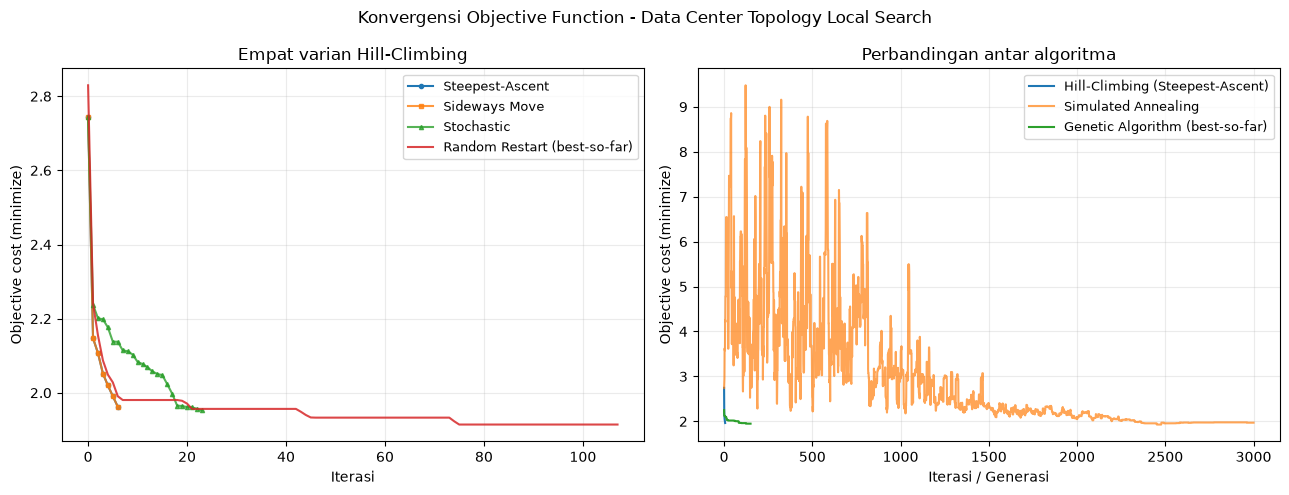

Algoritma                          Cost Awal    Cost Akhir
HC - Steepest-Ascent                  2.7453        1.9625
HC - Sideways Move                    2.7453        1.9625
HC - Stochastic                       2.7453        1.9524
HC - Random Restart                   (acak)        1.9143
Simulated Annealing                   2.7453        1.9290
Genetic Algorithm                     (acak)        1.9481


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(hc_history, marker="o", ms=3, label="Steepest-Ascent")
ax.plot(sw_history, marker="s", ms=3, alpha=0.8, label="Sideways Move")
ax.plot(st_history, marker="^", ms=3, alpha=0.8, label="Stochastic")
ax.plot(rr_history, alpha=0.85, label="Random Restart (best-so-far)")
ax.set_xlabel("Iterasi"); ax.set_ylabel("Objective cost (minimize)")
ax.set_title("Empat varian Hill-Climbing"); ax.legend(fontsize=9); ax.grid(alpha=0.25)

ax = axes[1]
ax.plot(hc_history, label="Hill-Climbing (Steepest-Ascent)")
ax.plot(sa_history, label="Simulated Annealing", alpha=0.7)
ax.plot(ga_history, label="Genetic Algorithm (best-so-far)")
ax.set_xlabel("Iterasi / Generasi"); ax.set_ylabel("Objective cost (minimize)")
ax.set_title("Perbandingan antar algoritma"); ax.legend(fontsize=9); ax.grid(alpha=0.25)

fig.suptitle("Konvergensi Objective Function - Data Center Topology Local Search")
fig.tight_layout()
plt.show()

init_cost = objective(A0, positions, WEIGHTS, PENALTY_BIG)["cost"]
print(f"{'Algoritma':<32}{'Cost Awal':>12}{'Cost Akhir':>14}")
print(f"{'HC - Steepest-Ascent':<32}{init_cost:>12.4f}{hc_history[-1]:>14.4f}")
print(f"{'HC - Sideways Move':<32}{init_cost:>12.4f}{sw_history[-1]:>14.4f}")
print(f"{'HC - Stochastic':<32}{init_cost:>12.4f}{st_history[-1]:>14.4f}")
print(f"{'HC - Random Restart':<32}{'(acak)':>12}{min(rr_costs):>14.4f}")
print(f"{'Simulated Annealing':<32}{init_cost:>12.4f}{min(sa_history):>14.4f}")
print(f"{'Genetic Algorithm':<32}{'(acak)':>12}{ga_history[-1]:>14.4f}")